24RB1074　半田悠人

## 課題1：仮説集合の作成

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [23]:
def make_W(m, B):
    W = []
    
    for _ in range(16):
        w = np.random.randint(-B, B + 1, size=m)
        W.append(w)
    
    return np.array(W)

def make_H(m, W):
    H = []
    for w in W:
        def f_w(x, w=w):
            return np.dot(w, x)
        
        H.append(f_w)
        
    return H

In [24]:
m = 10
B = np.array([1,3,5])
num_samples = 1000 # 各Bに対して1000個のHを生成

H_B = {1: [], 3: [], 5: []}

for b in B:

    for _ in range(num_samples):
        W = make_W(m, b)
        H = make_H(m, W)

        H_B[b].append(H)


## 課題2：Rademacher 複雑度関数の実装

In [25]:
def sup(sigma, H):
    results = []
    for f in H:
        results.append(f(sigma) / m)
    
    return max(results)

def Rademacher(H):
    all_sigmas = np.array(list(itertools.product([-1, 1], repeat=10)))
    
    return np.mean([sup(s, H) for s in all_sigmas])

In [26]:
results = {1: [], 3: [], 5: []}
for b in B:
    for H in H_B[b]:
        results[b].append(Rademacher(H))

## 課題3：プロット

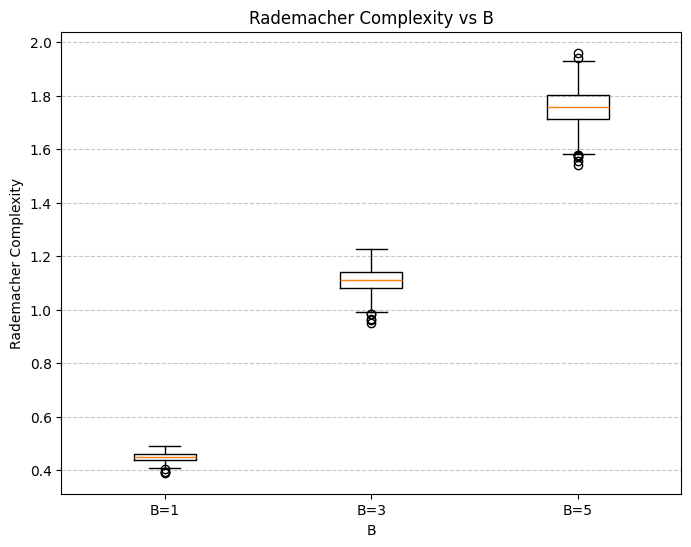

  箱ひげ図の統計データ ＆ ばらつきの解析詳細
【 B=1 】
  中央値: 0.4497
  最大値 / 最小値  : 0.4899 / 0.4085
  分散: 0.000232
  標準偏差: 0.0152 

【 B=3 】
  中央値: 1.1107
  最大値 / 最小値  : 1.2264 / 0.9925
  分散: 0.001832
  標準偏差: 0.0428 

【 B=5 】
  中央値: 1.7563
  最大値 / 最小値  : 1.9314 / 1.5825
  分散: 0.004384
  標準偏差: 0.0662 



In [27]:
# プロット用のデータ整形
data_to_plot = [results[1], results[3], results[5]]
labels = ['B=1', 'B=3', 'B=5']

# 箱ひげ図の作成
plt.figure(figsize=(8, 6))
bp = plt.boxplot(data_to_plot, tick_labels=labels)

plt.title('Rademacher Complexity vs B')
plt.xlabel('B')
plt.ylabel('Rademacher Complexity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 統計データ出力 ---

print("  箱ひげ図の統計データ ＆ ばらつきの解析詳細")


for i, B_val in enumerate([1, 3, 5]):
    label = f'B={B_val}'
    
    # 箱ひげ図のグラフ要素から座標を取得
    median = bp['medians'][i].get_ydata()[0]
    whisker_min = bp['whiskers'][2*i].get_ydata()[1]
    whisker_max = bp['whiskers'][2*i+1].get_ydata()[1]
    raw_data = results[B_val]
    variance = np.var(raw_data)      
    std_dev = np.std(raw_data)      
    
    print(f"【 {label} 】")
    print(f"  中央値: {median:.4f}")
    print(f"  最大値 / 最小値  : {whisker_max:.4f} / {whisker_min:.4f}")
    print(f"  分散: {variance:.6f}")
    print(f"  標準偏差: {std_dev:.4f} ")
    print()

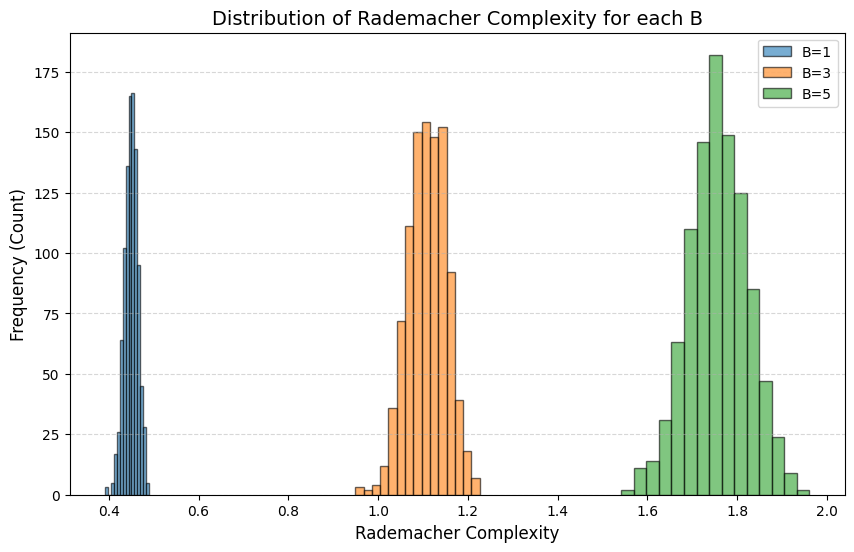

In [28]:
# 各BのRademacher複雑度のヒストグラム ---
plt.figure(figsize=(10, 6))

# 各Bのデータに対して色とラベルを指定してヒストグラムを描画
# binsの値（棒の数）を調整することで、分布の滑らかさを変更できます
plt.hist(results[1], bins=15, alpha=0.6, label='B=1', edgecolor='black')
plt.hist(results[3], bins=15, alpha=0.6, label='B=3', edgecolor='black')
plt.hist(results[5], bins=15, alpha=0.6, label='B=5', edgecolor='black')

# グラフの装飾
plt.title('Distribution of Rademacher Complexity for each B', fontsize=14)
plt.xlabel('Rademacher Complexity', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# 凡例を表示
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 描画
plt.show()

## 観察と考察

### 1. 箱ひげ図
* **中央値の単調増加:** $B$ の値の増加に伴い、中央値はおよそ線形に増加している。
* **分散の拡大:** $B$ の値の増加に伴い、箱の大きさ及び髭の長さが広がっている。出力にある、分散の増加を視覚的にも確認できる。
* **分布の対称性:** いずれの $B$ についても、中央値を対称軸に、上下で対称な分布となっている。
* **考察:** 今回の線形仮説集合において、 $B$ の値が大きくなると、各仮説が取りうるパラメータの絶対値の許容範囲が広がる。また、各要素の選択肢も $B = 1$ では $\{-1, 0, 1\}$ の3通り、 $B = 5$ では $\{-5,...,5\}$ の11通りと拡大し、仮説集合全体の表現力の総和が増加する。ゆえに、仮説集合の中に「$\sigma$ と符号が一致するような、絶対値の大きいベクトル $w$」含まれる確率および、サンプリングによって生じる仮説集合ごとの表現力の格差がともに増加し、複雑度と分散が増加したと考えられる。

### 2. ヒストグラム
* **分布の分離と位置:** $B=1, 3, 5$ の3つの分布は一切重なり合うことなく、完全に独立して分離している。 $B$ の値が大きくなるにつれて、分布の中心が複雑度が高い方へとシフトしている。
* **山の幅の変化:** $B$ の値の増加によって、分布の横幅が拡大し、鋭く尖った形状から裾野が広がった形状に遷移している。
* **分布の形状:** すべての $B$ において、分布は中央の平均値付近をピークとするベルカーブを描いている。
* **考察:** 分布の遷移および幅の変化は箱ひげ図の考察と同様。分布の形状について、プロットされている1つのデータ点は、$2^{10}$ = 1024通りにおよぶ全てのランダムラベル $\sigma$ に対する最大値の「標本平均」といえる。今回のシミュレーションは、すべての $\sigma$ を網羅して平均を求めた上で、それをさらに各Bで1000回サンプリングしたため、中心極限定理が発現し、ベルカーブが形成されたと考えられる。

## AI利用について
本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習

    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `list(itertools.product)`

* グラフのプロット（Copilotの活用）

    * 箱ひげ図とヒストグラムを描画するためのコード作成にCopilotを活用した。
    * 生成されたコードと出力されたグラフは自分で内容の確認と検証を行った。

* 考察の相談

    * 自分の仮説や、得られたシミュレーション結果に対する考察の蓋然性を確認した。
